Anomaly points: 304 / 30341 (1.00%)


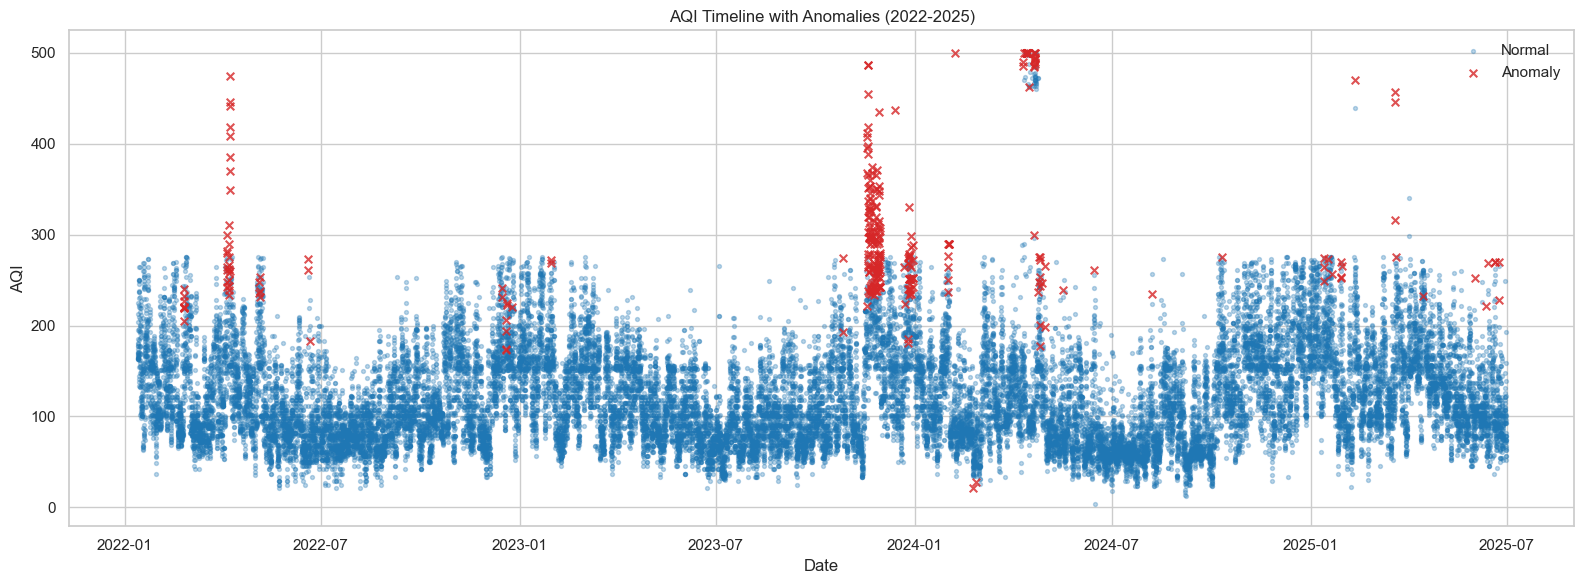


Anomaly by season:
             sum       pct
season_name               
Autumn       134  2.044865
Spring        83  0.939445
Summer        12  0.163399

Anomaly by month:
       sum       pct
month               
1       11  0.409226
2       20  0.737463
3        4  0.134363
4       73  2.533842
5        6  0.201545
6       11  0.381944
7        0  0.000000
8        1  0.044803
9        0  0.000000
10       3  0.134409
11     131  6.062008
12      44  1.991852

Anomaly by hour:
      sum       pct
hour               
0     304  1.001945


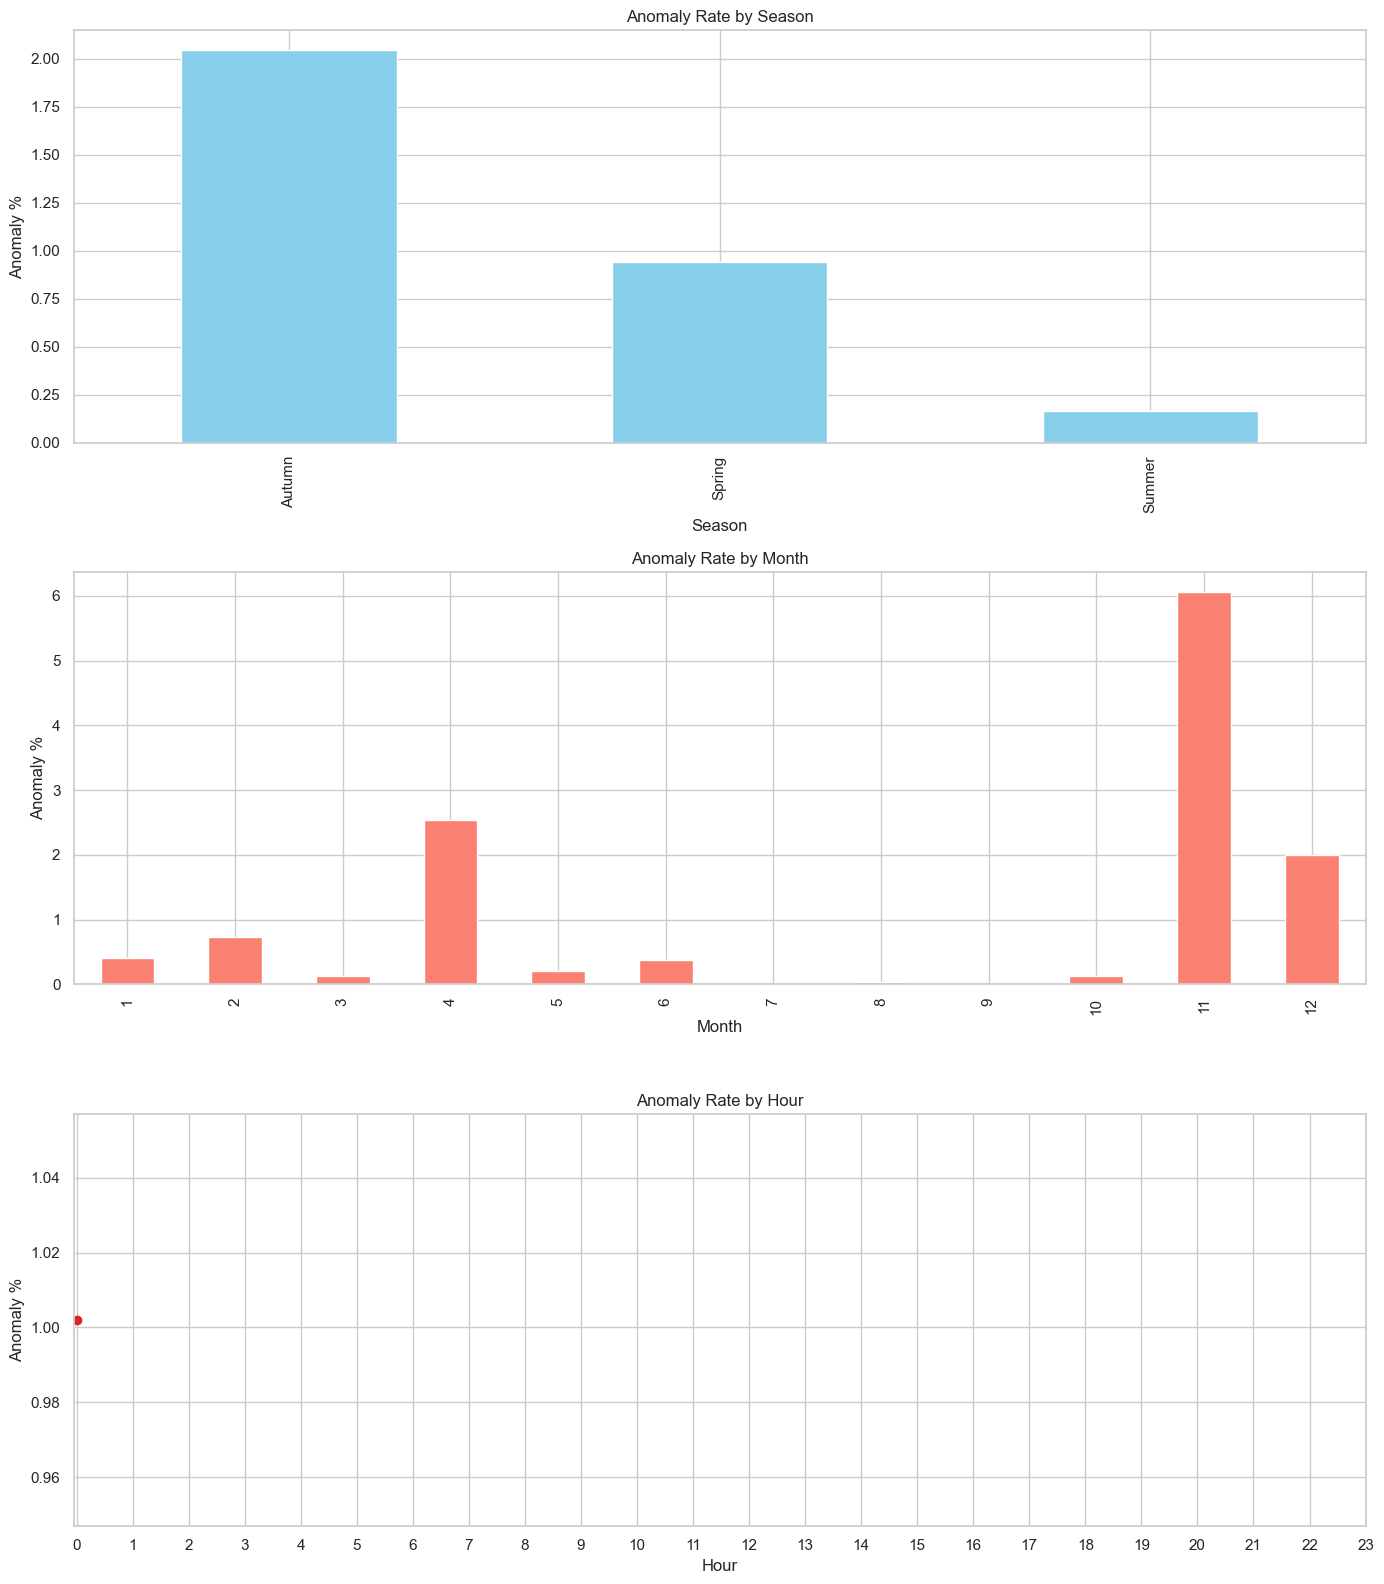

KeyError: 'mean'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

# Load data
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
df['local_time'] = pd.to_datetime(df['local_time'])
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M').dt.to_timestamp()

# Ensure correct column names
cols = ['aqi', 'pm25', 'temperature']
df = df.dropna(subset=cols)

# Anomaly detection với IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
yhat = iso.fit_predict(df[cols])
df['is_anomaly'] = (yhat == -1)

# Save clean data without anomalies
data_no_outlier = df[~df['is_anomaly']].copy()
data_no_outlier.to_csv('../data_no_outlier.csv', index=False)

# Counts
n_anomaly = df['is_anomaly'].sum()
pct_anomaly = n_anomaly / len(df) * 100
print(f"Anomaly points: {n_anomaly} / {len(df)} ({pct_anomaly:.2f}%)")

# Timeline plot
plt.figure(figsize=(16, 6))
plt.scatter(df.loc[~df['is_anomaly'], 'date'], df.loc[~df['is_anomaly'], 'aqi'],
            s=8, alpha=0.3, label='Normal', color='tab:blue')
plt.scatter(df.loc[df['is_anomaly'], 'date'], df.loc[df['is_anomaly'], 'aqi'],
            s=30, alpha=0.8, label='Anomaly', color='tab:red', marker='x')
plt.title('AQI Timeline with Anomalies (2022-2025)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()

# Season / month / hour analysis
season_map = {1: 'Spring', 2: 'Summer', 3: 'Autumn', 4: 'Winter'}
if 'season' in df.columns:
    df['season_name'] = df['season'].map(season_map)
else:
    df['month'] = df['date'].dt.month
    df['season_name'] = pd.cut(df['month'],
                               bins=[0, 3, 6, 9, 12],
                               labels=['Winter', 'Spring', 'Summer', 'Autumn'],
                               right=True)

df['hour'] = df['date'].dt.hour
df['month'] = df['date'].dt.month

season_anom = df.groupby('season_name')['is_anomaly'].agg(['sum', 'count'])
season_anom['pct'] = season_anom['sum'] / season_anom['count'] * 100
month_anom = df.groupby('month')['is_anomaly'].agg(['sum', 'count'])
month_anom['pct'] = month_anom['sum'] / month_anom['count'] * 100
hour_anom = df.groupby('hour')['is_anomaly'].agg(['sum', 'count'])
hour_anom['pct'] = hour_anom['sum'] / hour_anom['count'] * 100

print("\nAnomaly by season:")
print(season_anom[['sum', 'pct']])
print("\nAnomaly by month:")
print(month_anom[['sum', 'pct']])
print("\nAnomaly by hour:")
print(hour_anom[['sum', 'pct']].sort_values('pct', ascending=False).head(10))

# Plot seasonal/monthly/hourly anomaly rate
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
season_anom['pct'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Anomaly Rate by Season')
axes[0].set_ylabel('Anomaly %')
axes[0].set_xlabel('Season')

month_anom['pct'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Anomaly Rate by Month')
axes[1].set_ylabel('Anomaly %')
axes[1].set_xlabel('Month')

hour_anom['pct'].plot(kind='line', marker='o', ax=axes[2], color='tab:red')
axes[2].set_title('Anomaly Rate by Hour')
axes[2].set_ylabel('Anomaly %')
axes[2].set_xlabel('Hour')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Compare anomaly vs normal
compare_cols = ['aqi', 'pm25', 'temperature']
grouped = df.groupby('is_anomaly')[compare_cols].agg(['mean', 'std'])
# Flatten MultiIndex column names like ('aqi','mean') → 'aqi_mean'
grouped.columns = [f"{col[0]}_{col[1]}" for col in grouped.columns]

normal = grouped.loc[False]
anomaly = grouped.loc[True]

summary = pd.DataFrame({
    'normal_mean': normal[['aqi_mean', 'pm25_mean', 'temperature_mean']],
    'normal_std': normal[['aqi_std', 'pm25_std', 'temperature_std']],
    'anomaly_mean': anomaly[['aqi_mean', 'pm25_mean', 'temperature_mean']],
    'anomaly_std': anomaly[['aqi_std', 'pm25_std', 'temperature_std']],
})
summary['mean_diff'] = summary['anomaly_mean'] - summary['normal_mean']
summary['mean_diff_pct'] = summary['mean_diff'] / summary['normal_mean'].abs() * 100

summary.index = ['aqi', 'pm25', 'temperature']
print("\nAnomaly vs Normal characteristic comparison:")
print(summary[['normal_mean', 'anomaly_mean', 'mean_diff', 'mean_diff_pct']])
import json
from pathlib import Path
p = Path('Anomaly Detection_manual.ipynb')
with p.open('r', encoding='utf-8') as f:
    data = json.load(f)
for i, cell in enumerate(data['cells']):
    if cell['cell_type'] == 'code' and 'Compare anomaly vs normal' in ''.join(cell['source']):
        print('FOUND cell', i)
        print(''.join(cell['source']))
        break
else:
    print('NOT FOUND')
# Daily profile matrix: average AQI by hour for each day
daily = df.groupby(['date', 'hour'])['aqi'].mean().reset_index()
daily_matrix = daily.pivot(index='date', columns='hour', values='aqi')
daily_matrix = daily_matrix.reindex(columns=range(24))
daily_matrix = daily_matrix.interpolate(axis=1).fillna(method='ffill', axis=1).fillna(method='bfill', axis=1)
print(f"\nDaily profile matrix shape: {daily_matrix.shape}")

# Visualize sample daily profiles
sample_days = daily_matrix.sample(4, random_state=42)
plt.figure(figsize=(14, 8))
for day, row in sample_days.iterrows():
    plt.plot(range(24), row.values, marker='o', label=str(day.date()))
plt.title('Sample Daily AQI Profiles')
plt.xlabel('Hour')
plt.ylabel('Average AQI')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Heatmap first 100 days
plt.figure(figsize=(14, 8))
plt.imshow(daily_matrix.iloc[:100].values, aspect='auto', cmap='RdYlGn_r')
plt.colorbar(label='AQI')
plt.title('Daily AQI Profile Heatmap (First 100 Days)')
plt.xlabel('Hour')
plt.ylabel('Day index')
plt.show()